# Post 4: Mekanisme Pembelajaran Model

Bayangkan kamu ingin mengajari seorang anak kecil membedakan kucing dan anjing. Kamu akan menunjukkan banyak foto, memberikan penjelasan, dan kemudian menguji apakah ia bisa mengenali hewan baru yang belum pernah dilihat sebelumnya. Proses inilah yang secara kasar dilakukan oleh model machine learning.

Post ini membahas "dapur" dari machine learning: bagaimana model benar-benar belajar dari data, apa saja yang bisa salah, dan bagaimana kita mempersiapkan data dengan benar.

---

**Daftar Isi**
1. Konsep Training dan Testing
2. Apa itu Model dan Bagaimana Ia Belajar
3. Overfitting dan Underfitting
4. Bias-Variance Tradeoff
5. Data Preprocessing
6. Hyperparameter vs Parameter
7. Cross-Validation

In [1]:
# Impor semua library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.pipeline import make_pipeline

# Pengaturan tampilan grafik
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


---

## 1. Konsep Training dan Testing: Mengapa Data Dibagi

### Analogi Ujian Sekolah

Bayangkan kamu sedang belajar untuk ujian matematika. Kamu punya 100 soal latihan. Strategi belajar yang baik bukan menghafal semua 100 jawaban itu, melainkan memahami caranya sehingga bisa mengerjakan soal baru yang belum pernah dilihat.

Dalam machine learning, logikanya sama persis:

- **Data training** = soal latihan. Model belajar dari data ini.
- **Data testing** = soal ujian. Digunakan untuk menguji kemampuan model pada data yang belum pernah dilihat sebelumnya.

### Mengapa Tidak Pakai Semua Data untuk Training?

Jika model dilatih dan diuji pada data yang sama, nilai akurasinya akan tampak sangat tinggi, tapi itu menyesatkan. Model hanya "menghafal" jawaban, bukan benar-benar belajar. Saat diberi data baru, performanya bisa anjlok.

**Aturan umum:** 70-80% data untuk training, 20-30% untuk testing.

Total data     : 100 sampel
Data training  : 80 sampel (80%)
Data testing   : 20 sampel (20%)


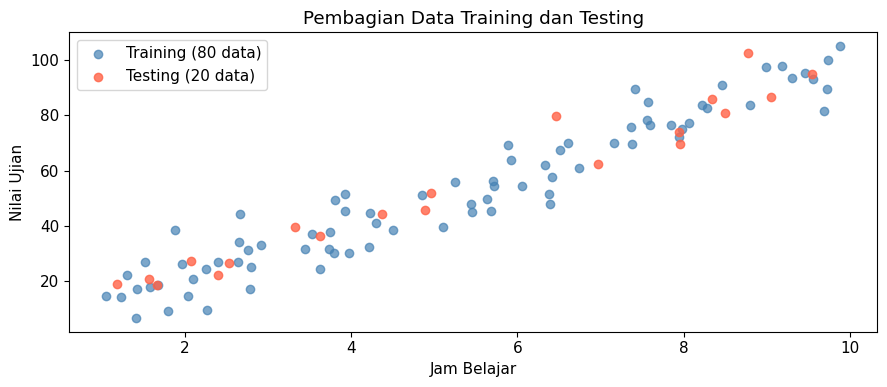

In [2]:
# Membuat contoh data sederhana:
# hubungan antara jam belajar dan nilai ujian siswa

np.random.seed(42)
jam_belajar = np.random.uniform(1, 10, 100).reshape(-1, 1)  # fitur (input)
nilai_ujian = 10 * jam_belajar.flatten() + np.random.normal(0, 8, 100)  # target (output)

# Membagi data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    jam_belajar,     # fitur
    nilai_ujian,     # target
    test_size=0.2,   # 20% untuk testing
    random_state=42  # agar hasil bisa direproduksi
)

print(f"Total data     : {len(jam_belajar)} sampel")
print(f"Data training  : {len(X_train)} sampel ({len(X_train)/len(jam_belajar)*100:.0f}%)")
print(f"Data testing   : {len(X_test)} sampel ({len(X_test)/len(jam_belajar)*100:.0f}%)")

# Visualisasi pembagian data
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_train, y_train, color='steelblue', label=f'Training ({len(X_train)} data)', alpha=0.7)
ax.scatter(X_test,  y_test,  color='tomato',    label=f'Testing ({len(X_test)} data)',  alpha=0.8)
ax.set_xlabel('Jam Belajar')
ax.set_ylabel('Nilai Ujian')
ax.set_title('Pembagian Data Training dan Testing')
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. Apa itu Model dan Bagaimana Model "Belajar"

### Model = Fungsi yang Memetakan Input ke Output

Sebuah model machine learning pada dasarnya adalah sebuah fungsi matematika. Ia menerima input (fitur) dan menghasilkan output (prediksi).

Contoh paling sederhana adalah **Linear Regression**:

```
prediksi_nilai = (bobot x jam_belajar) + bias
```

Di sini:
- **bobot** dan **bias** adalah nilai yang belum diketahui. Inilah yang harus dipelajari oleh model.
- Proses "belajar" = mencari nilai bobot dan bias yang paling pas agar prediksi model sedekat mungkin dengan nilai sebenarnya.

### Proses Belajar: Meminimalkan Kesalahan

Model belajar dengan cara terus-menerus memperbaiki dirinya. Di setiap langkah:

1. Model membuat prediksi berdasarkan bobot yang dimiliki saat ini
2. Prediksi dibandingkan dengan jawaban sebenarnya
3. Kesalahan (error) dihitung
4. Bobot diperbarui sedikit agar error berkurang

Proses ini diulang ratusan hingga ribuan kali hingga model konvergen, artinya perubahan bobot sudah sangat kecil dan model dianggap cukup baik.

Hasil belajar model:
  Bobot (weight) : 9.6432
  Bias           : 1.5001

Formula model  : nilai = 9.64 x jam_belajar + (1.50)
Formula asli   : nilai = 10.00 x jam_belajar + noise

(Model berhasil mendekati pola asli dari data!)


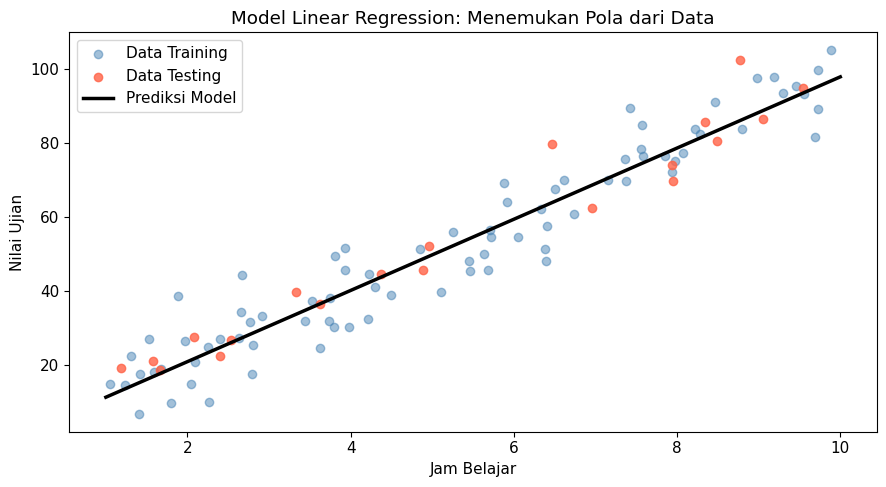

In [3]:
# Melatih model Linear Regression dengan data training
model = LinearRegression()
model.fit(X_train, y_train)  # proses "belajar" terjadi di sini

# Melihat apa yang berhasil dipelajari model
print("Hasil belajar model:")
print(f"  Bobot (weight) : {model.coef_[0]:.4f}")
print(f"  Bias           : {model.intercept_:.4f}")
print(f"\nFormula model  : nilai = {model.coef_[0]:.2f} x jam_belajar + ({model.intercept_:.2f})")
print(f"Formula asli   : nilai = 10.00 x jam_belajar + noise")
print("\n(Model berhasil mendekati pola asli dari data!)")

# Visualisasi: model sebagai garis prediksi
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train, y_train, color='steelblue', label='Data Training', alpha=0.5)
ax.scatter(X_test,  y_test,  color='tomato',    label='Data Testing',  alpha=0.8)

x_line = np.linspace(1, 10, 100).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color='black', linewidth=2.5, label='Prediksi Model')

ax.set_xlabel('Jam Belajar')
ax.set_ylabel('Nilai Ujian')
ax.set_title('Model Linear Regression: Menemukan Pola dari Data')
ax.legend()
plt.tight_layout()
plt.show()

---

## 3. Overfitting dan Underfitting

Dua masalah klasik yang paling sering ditemui dalam machine learning adalah **underfitting** dan **overfitting**.

### Analogi: Belajar Memasak dari Buku Resep

- **Underfitting:** Kamu hanya membaca judul resep tanpa memahami isinya. Hasilnya, masakan tidak matang dengan benar karena kamu tidak paham prosesnya. Model terlalu sederhana untuk menangkap pola yang ada di data.

- **Overfitting:** Kamu menghafal setiap kata dalam buku resep, termasuk catatan kaki dan koreksi kesalahan cetak. Kamu bisa memasak resep itu persis seperti buku, tapi tidak bisa membuat variasi atau berimprovisasi. Model terlalu "menghafal" data training dan gagal di data baru.

- **Good Fit:** Kamu memahami teknik dasar memasak. Kamu tidak hafal setiap detail, tapi bisa memasak berbagai hidangan dan beradaptasi dengan bahan yang tersedia.

| Kondisi | Performa Training | Performa Testing | Masalah |
|---|---|---|---|
| Underfitting | Buruk | Buruk | Model terlalu sederhana |
| Good Fit | Baik | Baik | Ideal |
| Overfitting | Sangat Baik | Buruk | Model terlalu kompleks |

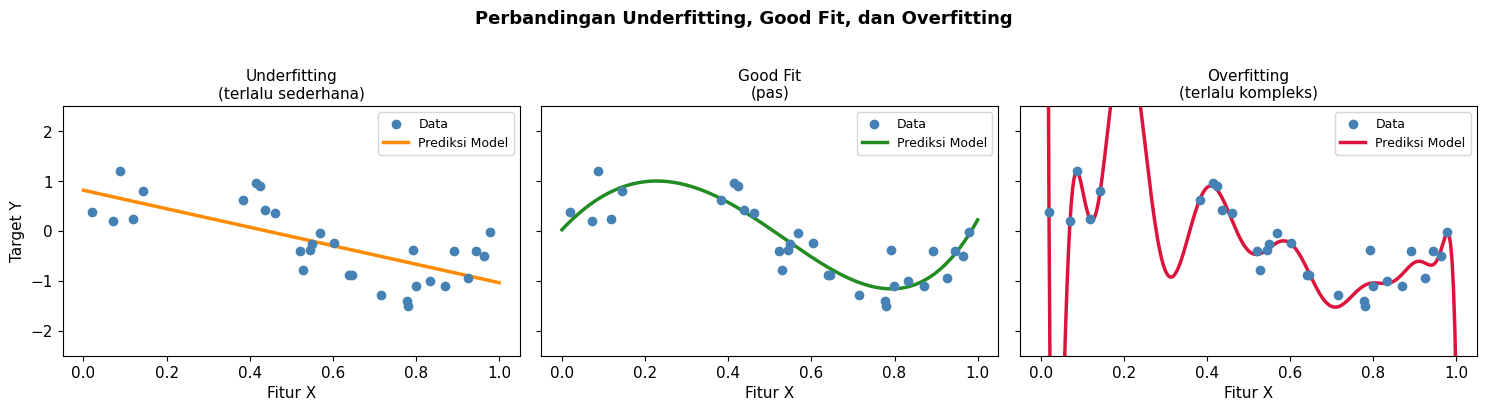

In [4]:
# Data dengan pola sinusoidal dan sedikit noise
np.random.seed(0)
X_demo   = np.sort(np.random.uniform(0, 1, 30))
y_demo   = np.sin(2 * np.pi * X_demo) + np.random.normal(0, 0.3, 30)
X_demo_r = X_demo.reshape(-1, 1)

x_plot = np.linspace(0, 1, 300).reshape(-1, 1)

# Tiga model dengan kompleksitas berbeda
model_under = make_pipeline(PolynomialFeatures(1),  LinearRegression())  # garis lurus
model_good  = make_pipeline(PolynomialFeatures(4),  LinearRegression())  # pas
model_over  = make_pipeline(PolynomialFeatures(15), LinearRegression())  # terlalu kompleks

for m in [model_under, model_good, model_over]:
    m.fit(X_demo_r, y_demo)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

configs = [
    ('Underfitting\n(terlalu sederhana)', model_under, 'darkorange'),
    ('Good Fit\n(pas)',                   model_good,  'forestgreen'),
    ('Overfitting\n(terlalu kompleks)',   model_over,  'crimson'),
]

for ax, (title, mdl, color) in zip(axes, configs):
    ax.scatter(X_demo, y_demo, color='steelblue', zorder=3, label='Data')
    ax.plot(x_plot, mdl.predict(x_plot), color=color, linewidth=2.5, label='Prediksi Model')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Fitur X')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Target Y')
plt.suptitle('Perbandingan Underfitting, Good Fit, dan Overfitting', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Bias-Variance Tradeoff

Bias-variance tradeoff adalah konsep yang menjelaskan secara lebih formal mengapa underfitting dan overfitting bisa terjadi, dan mengapa keduanya sulit dihindari secara bersamaan.

### Apa itu Bias?

**Bias** adalah error yang terjadi karena asumsi model terlalu sederhana sehingga tidak bisa menangkap pola yang sesungguhnya ada di data.

- Bias tinggi = underfitting
- Analogi: seorang penembak yang selalu meleset ke kiri secara konsisten. Ia punya "bias" ke kiri.

### Apa itu Variance?

**Variance** adalah seberapa besar perubahan prediksi model ketika data training diganti dengan data lain. Model dengan variance tinggi sangat sensitif terhadap data training: ganti sedikit datanya, prediksinya berubah drastis.

- Variance tinggi = overfitting
- Analogi: seorang penembak yang tembakannya tersebar acak ke segala penjuru. Tidak konsisten.

### Hubungannya dengan Overfitting dan Underfitting

| Kondisi | Bias | Variance |
|---|---|---|
| Underfitting | Tinggi | Rendah |
| Good Fit | Rendah | Rendah |
| Overfitting | Rendah | Tinggi |

### The Tradeoff

Menurunkan bias (membuat model lebih kompleks) biasanya menaikkan variance, dan sebaliknya. Tujuan kita adalah menemukan titik keseimbangan di mana total error paling kecil.

```
Total Error = Bias^2 + Variance + Irreducible Noise
```

"Irreducible noise" adalah error yang berasal dari ketidakpastian alami dalam data. Ini tidak bisa dihilangkan, berapa pun kompleksitas modelnya.

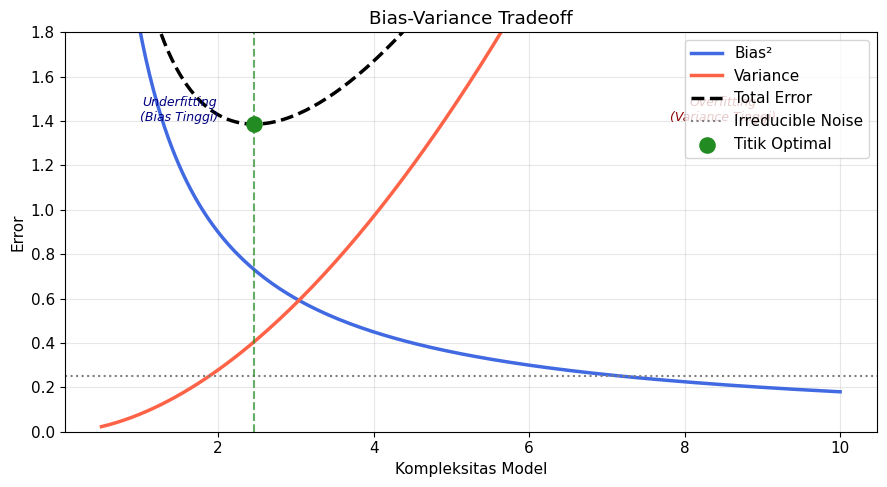

In [5]:
# Visualisasi Bias-Variance Tradeoff
complexities = np.linspace(0.5, 10, 200)

bias_sq    = 1.8 / complexities               # bias menurun saat model makin kompleks
variance   = 0.08 * complexities ** 1.8       # variance naik saat model makin kompleks
noise      = 0.25                             # irreducible noise (konstan)
total_err  = bias_sq + variance + noise

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(complexities, bias_sq,   color='royalblue',  linewidth=2.5,                  label='Bias²')
ax.plot(complexities, variance,  color='tomato',     linewidth=2.5,                  label='Variance')
ax.plot(complexities, total_err, color='black',      linewidth=2.5, linestyle='--',  label='Total Error')
ax.axhline(y=noise, color='gray', linestyle=':', linewidth=1.5, label='Irreducible Noise')

# Titik optimal
idx_min = np.argmin(total_err)
ax.axvline(x=complexities[idx_min], color='forestgreen', linestyle='--', alpha=0.7)
ax.scatter([complexities[idx_min]], [total_err[idx_min]],
           color='forestgreen', s=120, zorder=5, label='Titik Optimal')

ax.text(1.5, 1.4, 'Underfitting\n(Bias Tinggi)',     ha='center', fontsize=9, color='navy',    style='italic')
ax.text(8.5, 1.4, 'Overfitting\n(Variance Tinggi)',  ha='center', fontsize=9, color='darkred', style='italic')

ax.set_xlabel('Kompleksitas Model')
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Tradeoff')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Data Preprocessing: Konsep Dasar

Sebelum melatih model, data perlu dipersiapkan terlebih dahulu. Data dunia nyata jarang sekali dalam kondisi "bersih" dan siap pakai. Proses persiapan data ini disebut **preprocessing**.

Bayangkan kamu sedang membuat adonan kue. Sebelum mencampur semua bahan, kamu harus mengayak tepung, mengukur takaran yang tepat, dan menyiapkan setiap bahan dalam kondisi yang sesuai. Preprocessing data bekerja dengan cara yang sama.

Tiga hal yang akan kita bahas:
- Menangani data yang hilang (missing values)
- Menyeragamkan skala fitur (normalization dan standardization)
- Mengubah data teks menjadi angka (encoding)

### 5.1 Missing Values: Menangani Data yang Hilang

Data yang hilang (missing values) sangat umum ditemui di dunia nyata. Penyebabnya bisa bermacam-macam: responden tidak mengisi formulir, sensor rusak, atau data memang tidak tersedia.

Ada tiga pendekatan utama:

1. **Drop (hapus):** Hapus baris atau kolom yang memiliki data hilang. Cocok jika jumlah data hilang sangat sedikit.
2. **Isi dengan mean atau median:** Isi dengan rata-rata (mean) atau nilai tengah (median). Cocok untuk data numerik.
3. **Isi dengan modus:** Isi dengan nilai yang paling sering muncul. Cocok untuk data kategorikal.

In [6]:
# Membuat contoh data dengan missing values
data_siswa = pd.DataFrame({
    'nama'       : ['Andi', 'Budi', 'Citra', 'Dian', 'Eko'],
    'nilai_mtk'  : [85, np.nan, 78, 90, np.nan],
    'nilai_ipa'  : [70, 80, np.nan, 75, 88],
    'kota_asal'  : ['Jakarta', 'Bandung', None, 'Surabaya', 'Bandung']
})

print("Data asli (NaN = data hilang):")
print(data_siswa)
print(f"\nJumlah missing values per kolom:")
print(data_siswa.isnull().sum())

Data asli (NaN = data hilang):
    nama  nilai_mtk  nilai_ipa kota_asal
0   Andi       85.0       70.0   Jakarta
1   Budi        NaN       80.0   Bandung
2  Citra       78.0        NaN      None
3   Dian       90.0       75.0  Surabaya
4    Eko        NaN       88.0   Bandung

Jumlah missing values per kolom:
nama         0
nilai_mtk    2
nilai_ipa    1
kota_asal    1
dtype: int64


In [7]:
# Mengisi nilai numerik dengan rata-rata (mean)
data_siswa['nilai_mtk'] = data_siswa['nilai_mtk'].fillna(data_siswa['nilai_mtk'].mean())
data_siswa['nilai_ipa'] = data_siswa['nilai_ipa'].fillna(data_siswa['nilai_ipa'].mean())

# Mengisi nilai kategorikal dengan modus (nilai yang paling sering muncul)
data_siswa['kota_asal'] = data_siswa['kota_asal'].fillna(data_siswa['kota_asal'].mode()[0])

print("Data setelah penanganan missing values:")
print(data_siswa.round(2))
print(f"\nJumlah missing values per kolom setelah diisi:")
print(data_siswa.isnull().sum())

Data setelah penanganan missing values:
    nama  nilai_mtk  nilai_ipa kota_asal
0   Andi      85.00      70.00   Jakarta
1   Budi      84.33      80.00   Bandung
2  Citra      78.00      78.25   Bandung
3   Dian      90.00      75.00  Surabaya
4    Eko      84.33      88.00   Bandung

Jumlah missing values per kolom setelah diisi:
nama         0
nilai_mtk    0
nilai_ipa    0
kota_asal    0
dtype: int64


### 5.2 Normalization vs Standardization

Bayangkan kamu ingin membandingkan nilai ujian (skala 0-100) dengan tinggi badan siswa (skala 150-180 cm). Skala keduanya sangat berbeda, dan ini bisa membingungkan model karena ia mungkin salah mengira bahwa fitur dengan angka lebih besar itu "lebih penting".

**Normalization (Min-Max Scaling):** Mengubah semua nilai ke rentang 0 sampai 1.

```
nilai_baru = (nilai - nilai_minimum) / (nilai_maksimum - nilai_minimum)
```

**Standardization (Z-score Scaling):** Mengubah data agar memiliki rata-rata 0 dan standar deviasi 1.

```
nilai_baru = (nilai - rata-rata) / standar_deviasi
```

**Kapan memakai yang mana?**
- Gunakan **normalization** jika kamu tahu rentang nilai yang pasti dan distribusi datamu cukup merata.
- Gunakan **standardization** jika datamu memiliki nilai pencilan (outlier). Cara ini lebih umum dan lebih robust dalam praktik.

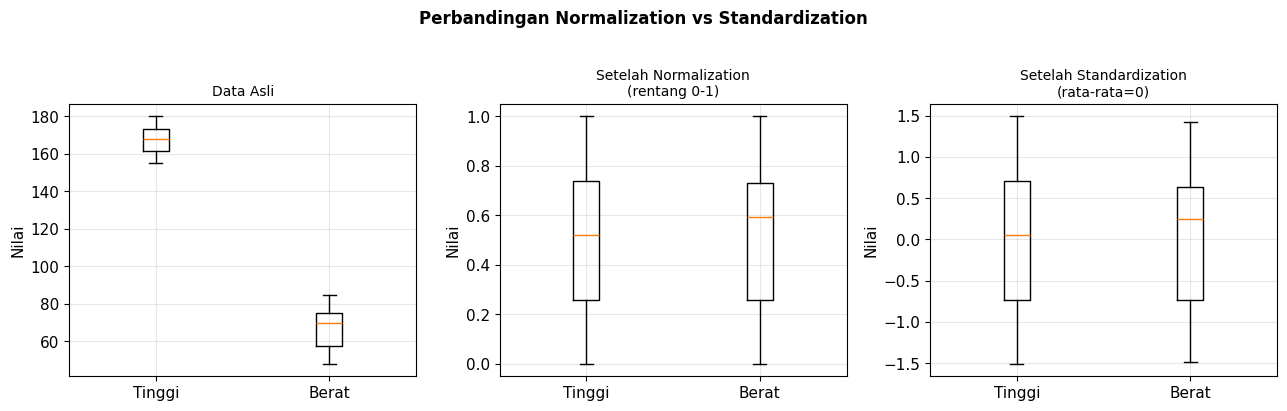

Rentang data asli:
  Tinggi : 155 - 180 cm
  Berat  : 48 - 85 kg

Setelah Normalization (semua fitur masuk rentang 0-1):
   tinggi_cm  berat_kg
0       0.12     0.054
1       0.40     0.459
2       0.68     0.649
3       1.00     1.000
4       0.00     0.000
5       0.52     0.595
6       0.80     0.811

Setelah Standardization (rata-rata mendekati 0):
   tinggi_cm  berat_kg
0     -1.149    -1.325
1     -0.309    -0.146
2      0.532     0.404
3      1.492     1.426
4     -1.509    -1.482
5      0.051     0.247
6      0.892     0.876


In [8]:
# Contoh data dengan skala berbeda
data_fisik = pd.DataFrame({
    'tinggi_cm' : [158, 165, 172, 180, 155, 168, 175],
    'berat_kg'  : [50, 65, 72, 85, 48, 70, 78]
})

# Normalization (Min-Max)
scaler_norm = MinMaxScaler()
data_norm = pd.DataFrame(scaler_norm.fit_transform(data_fisik), columns=data_fisik.columns)

# Standardization (Z-score)
scaler_std = StandardScaler()
data_std = pd.DataFrame(scaler_std.fit_transform(data_fisik), columns=data_fisik.columns)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, data, title in zip(
    axes,
    [data_fisik, data_norm, data_std],
    ['Data Asli', 'Setelah Normalization\n(rentang 0-1)', 'Setelah Standardization\n(rata-rata=0)']
):
    ax.boxplot([data['tinggi_cm'], data['berat_kg']], labels=['Tinggi', 'Berat'])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Nilai')
    ax.grid(alpha=0.3)

plt.suptitle('Perbandingan Normalization vs Standardization', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Rentang data asli:")
print(f"  Tinggi : {data_fisik['tinggi_cm'].min()} - {data_fisik['tinggi_cm'].max()} cm")
print(f"  Berat  : {data_fisik['berat_kg'].min()} - {data_fisik['berat_kg'].max()} kg")
print("\nSetelah Normalization (semua fitur masuk rentang 0-1):")
print(data_norm.round(3))
print("\nSetelah Standardization (rata-rata mendekati 0):")
print(data_std.round(3))

### 5.3 Encoding Categorical Variables

Model machine learning bekerja dengan angka, bukan teks. Kolom seperti `kota_asal` atau `jenis_kelamin` perlu diubah menjadi angka terlebih dahulu. Proses ini disebut **encoding**.

Ada dua cara utama:

**1. Label Encoding:** Mengganti setiap kategori dengan sebuah angka urut.
- Contoh: Jakarta = 0, Bandung = 1, Surabaya = 2
- Cocok untuk data **ordinal** (yang memiliki urutan alami), seperti: rendah, sedang, tinggi.

**2. One-Hot Encoding:** Membuat kolom baru untuk setiap kategori dengan nilai 0 atau 1.
- Cocok untuk data **nominal** (yang tidak memiliki urutan), seperti nama kota atau warna.
- Menghindari model salah mengira ada hubungan hierarki antar kategori. Misalnya, jika Surabaya diberi angka 2 dan Jakarta diberi angka 0, model mungkin mengira "Surabaya lebih besar dari Jakarta" hanya karena angkanya lebih besar.

In [9]:
# Contoh data dengan kolom kategorikal
data_encoding = pd.DataFrame({
    'nama'  : ['Andi', 'Budi', 'Citra', 'Dian', 'Eko'],
    'kota'  : ['Jakarta', 'Bandung', 'Jakarta', 'Surabaya', 'Bandung'],
    'level' : ['Rendah', 'Tinggi', 'Sedang', 'Tinggi', 'Rendah']
})

print("Data asli:")
print(data_encoding)

# Label Encoding untuk 'level' (ada urutan: Rendah < Sedang < Tinggi)
le = LabelEncoder()
level_encoded = le.fit_transform(data_encoding['level'])
print(f"\nLabel Encoding untuk kolom 'level':")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding untuk 'kota' (tidak ada urutan)
kota_encoded = pd.get_dummies(data_encoding['kota'], prefix='kota')

# Gabungkan semua kolom
data_final = pd.concat([
    data_encoding[['nama']],
    kota_encoded,
    pd.Series(level_encoded, name='level_encoded')
], axis=1)

print("\nHasil akhir setelah encoding (siap dimasukkan ke model):")
print(data_final)

Data asli:
    nama      kota   level
0   Andi   Jakarta  Rendah
1   Budi   Bandung  Tinggi
2  Citra   Jakarta  Sedang
3   Dian  Surabaya  Tinggi
4    Eko   Bandung  Rendah

Label Encoding untuk kolom 'level':
{'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}

Hasil akhir setelah encoding (siap dimasukkan ke model):
    nama  kota_Bandung  kota_Jakarta  kota_Surabaya  level_encoded
0   Andi         False          True          False              0
1   Budi          True         False          False              2
2  Citra         False          True          False              1
3   Dian         False         False           True              2
4    Eko          True         False          False              0


---

## 6. Hyperparameter vs Parameter

Ini adalah perbedaan yang sering membingungkan pemula, tapi konsepnya cukup intuitif.

### Parameter: Yang Dipelajari oleh Model

**Parameter** adalah nilai internal yang dipelajari oleh model selama proses training. Kamu tidak menentukan nilainya secara langsung karena itu tugas model.

Contoh parameter:
- Bobot (weight) dan bias dalam linear regression
- Bobot koneksi antar neuron dalam neural network

### Hyperparameter: Yang Kamu Tentukan Sebelum Training

**Hyperparameter** adalah pengaturan yang kamu tentukan sebelum proses training dimulai. Model tidak bisa mempelajari ini sendiri karena hyperparameter mengendalikan cara model belajar, bukan apa yang dipelajari.

**Analogi:** Bayangkan kamu melatih seorang atlet:
- **Hyperparameter** = jadwal latihan, intensitas, durasi istirahat. Kamu sebagai pelatih yang menentukan ini.
- **Parameter** = kekuatan otot, teknik, dan refleks si atlet. Ini berkembang sendiri selama proses latihan.

### Contoh Hyperparameter Umum

| Hyperparameter | Digunakan di | Fungsi |
|---|---|---|
| `max_depth` | Decision Tree, XGBoost | Kedalaman maksimum pohon keputusan |
| `n_estimators` | Random Forest | Jumlah pohon yang dibuat |
| `learning_rate` | Gradient Boosting, Neural Network | Seberapa besar langkah pembaruan bobot per iterasi |
| `n_neighbors` | KNN | Jumlah tetangga yang dipertimbangkan |
| `C` | SVM | Seberapa ketat batas keputusan |

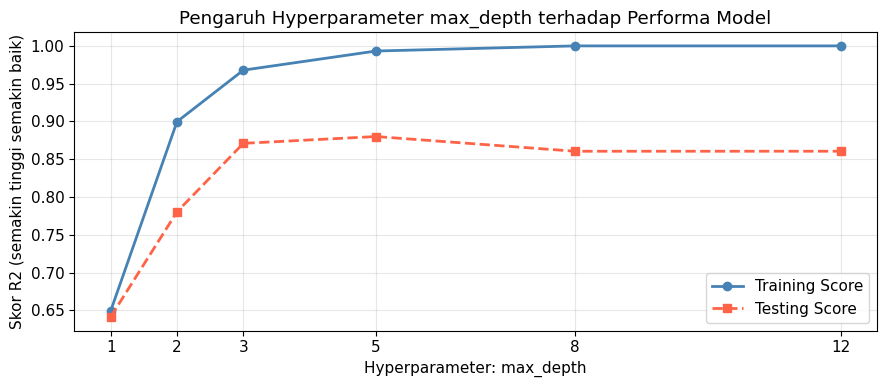

Skor training vs testing untuk setiap nilai max_depth:
  max_depth= 1 | train=0.649 | test=0.641 | gap=0.008
  max_depth= 2 | train=0.900 | test=0.780 | gap=0.119
  max_depth= 3 | train=0.968 | test=0.871 | gap=0.097
  max_depth= 5 | train=0.993 | test=0.880 | gap=0.113
  max_depth= 8 | train=1.000 | test=0.861 | gap=0.139
  max_depth=12 | train=1.000 | test=0.861 | gap=0.139


In [10]:
# Menunjukkan pengaruh hyperparameter max_depth pada Decision Tree
np.random.seed(42)
X_hp, y_hp = make_regression(n_samples=80, n_features=1, noise=20, random_state=42)
X_hp_train, X_hp_test, y_hp_train, y_hp_test = train_test_split(
    X_hp, y_hp, test_size=0.3, random_state=42
)

max_depths   = [1, 2, 3, 5, 8, 12]
train_scores = []
test_scores  = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_hp_train, y_hp_train)
    train_scores.append(tree.score(X_hp_train, y_hp_train))
    test_scores.append(tree.score(X_hp_test, y_hp_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(max_depths, train_scores, 'o-',  color='steelblue', label='Training Score', linewidth=2)
ax.plot(max_depths, test_scores,  's--', color='tomato',    label='Testing Score',  linewidth=2)
ax.set_xlabel('Hyperparameter: max_depth')
ax.set_ylabel('Skor R2 (semakin tinggi semakin baik)')
ax.set_title('Pengaruh Hyperparameter max_depth terhadap Performa Model')
ax.legend()
ax.set_xticks(max_depths)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Skor training vs testing untuk setiap nilai max_depth:")
for d, tr, te in zip(max_depths, train_scores, test_scores):
    gap = tr - te
    catatan = "  <-- mulai overfitting" if gap > 0.2 else ""
    print(f"  max_depth={d:2d} | train={tr:.3f} | test={te:.3f} | gap={gap:.3f}{catatan}")

---

## 7. Cross-Validation

### Masalah dengan Single Train-Test Split

Membagi data satu kali memiliki kelemahan: hasilnya bergantung pada keberuntungan pembagian.

Bayangkan kamu menguji kemampuan memasak seseorang hanya dengan satu hidangan. Jika kebetulan itu hidangan favoritnya, hasilnya terlihat bagus. Jika bukan, hasilnya buruk. Satu kali pengujian tidak bisa diandalkan untuk menggambarkan kemampuan sesungguhnya.

Hal yang sama berlaku untuk model machine learning. Satu kali pembagian mungkin kebetulan menghasilkan training set yang "mudah" atau testing set yang "mudah", sehingga hasilnya tidak representatif.

### K-Fold Cross-Validation

**K-Fold Cross-Validation** membagi data menjadi K bagian yang sama besar (disebut "fold"). Proses training dan testing kemudian diulang K kali, di mana setiap fold mendapat giliran menjadi data testing tepat satu kali.

Contoh dengan K=5:
- **Iterasi 1:** Fold 1 = Testing, Fold 2+3+4+5 = Training
- **Iterasi 2:** Fold 2 = Testing, Fold 1+3+4+5 = Training
- **Iterasi 3:** Fold 3 = Testing, Fold 1+2+4+5 = Training
- ... dan seterusnya

Hasil akhirnya adalah rata-rata dari semua K iterasi. Cara ini memberikan estimasi performa yang jauh lebih stabil dan terpercaya dibandingkan satu kali pembagian saja.

**Nilai K yang umum digunakan:** 5 atau 10.

In [11]:
# Perbandingan: Single Train-Test Split vs 5-Fold Cross-Validation
np.random.seed(42)
X_cv, y_cv = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
model_cv = LinearRegression()

# Metode 1: Single train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X_cv, y_cv, test_size=0.2, random_state=42)
model_cv.fit(X_tr, y_tr)
skor_single = model_cv.score(X_te, y_te)

# Metode 2: 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skor_cv = cross_val_score(model_cv, X_cv, y_cv, cv=kf, scoring='r2')

print("Hasil Single Train-Test Split:")
print(f"  Skor R2 : {skor_single:.4f}")
print(f"  (hanya satu angka -- tidak tahu apakah ini representatif)")

print("\nHasil 5-Fold Cross-Validation:")
for i, skor in enumerate(skor_cv, 1):
    print(f"  Fold {i}: {skor:.4f}")
print(f"\n  Rata-rata : {skor_cv.mean():.4f}  (estimasi performa yang lebih andal)")
print(f"  Std Dev   : {skor_cv.std():.4f}  (semakin kecil = semakin stabil)")

Hasil Single Train-Test Split:
  Skor R2 : 0.8742
  (hanya satu angka -- tidak tahu apakah ini representatif)

Hasil 5-Fold Cross-Validation:
  Fold 1: 0.8742
  Fold 2: 0.9397
  Fold 3: 0.9398
  Fold 4: 0.8620
  Fold 5: 0.8236

  Rata-rata : 0.8878  (estimasi performa yang lebih andal)
  Std Dev   : 0.0455  (semakin kecil = semakin stabil)


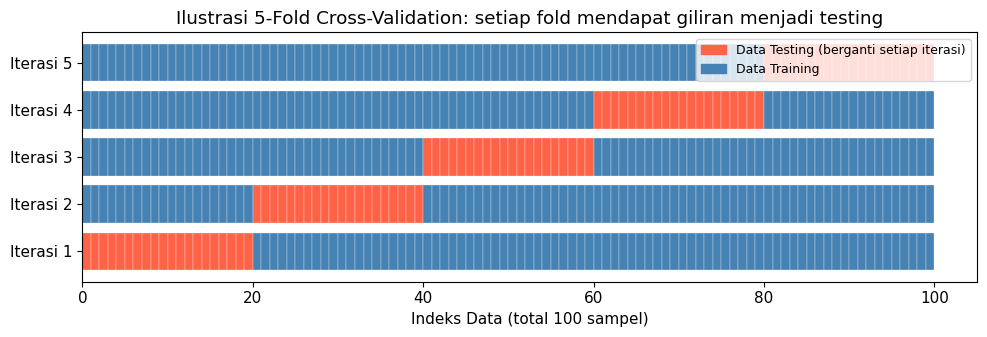

In [12]:
# Visualisasi cara kerja K-Fold
n_samples = 100
n_splits  = 5
fold_size = n_samples // n_splits

fig, ax = plt.subplots(figsize=(10, 3.5))

for fold_idx in range(n_splits):
    test_start = fold_idx * fold_size
    test_end   = (fold_idx + 1) * fold_size
    for sample_idx in range(n_samples):
        is_test = (test_start <= sample_idx < test_end)
        color   = 'tomato' if is_test else 'steelblue'
        ax.barh(fold_idx, 1, left=sample_idx, color=color, edgecolor='white', linewidth=0.2)

ax.set_yticks(range(n_splits))
ax.set_yticklabels([f'Iterasi {i+1}' for i in range(n_splits)])
ax.set_xlabel('Indeks Data (total 100 sampel)')
ax.set_title('Ilustrasi 5-Fold Cross-Validation: setiap fold mendapat giliran menjadi testing')

legend_el = [
    mpatches.Patch(color='tomato',    label='Data Testing (berganti setiap iterasi)'),
    mpatches.Patch(color='steelblue', label='Data Training')
]
ax.legend(handles=legend_el, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---

## Ringkasan

| Konsep | Inti Pemahaman |
|---|---|
| **Training vs Testing** | Data harus dipisah agar evaluasi model jujur dan tidak menyesatkan |
| **Model** | Fungsi matematika dengan parameter yang dipelajari dari data |
| **Overfitting** | Model menghafal data training, gagal di data baru |
| **Underfitting** | Model terlalu sederhana, tidak bisa menangkap pola |
| **Bias** | Error akibat model terlalu sederhana (hubungan dengan underfitting) |
| **Variance** | Sensitivitas model terhadap perubahan data training (hubungan dengan overfitting) |
| **Missing Values** | Tangani dengan menghapus, mengisi mean/median, atau modus |
| **Normalization / Standardization** | Menyeragamkan skala fitur agar model tidak "bingung" |
| **Encoding** | Mengubah data kategorikal menjadi angka agar bisa diproses model |
| **Parameter** | Nilai internal yang dipelajari model selama training (contoh: bobot, bias) |
| **Hyperparameter** | Pengaturan yang kita tentukan sebelum training dimulai (contoh: max_depth) |
| **Cross-Validation** | Evaluasi yang lebih andal dengan membagi data K kali secara bergantian |

---

**Post Berikutnya:** Metrik Evaluasi Model -- bagaimana mengukur "seberapa baik" model benar-benar bekerja, dan mengapa akurasi saja seringkali tidak cukup.